In [141]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [25]:
def fetch_dollar_cost(start_date, end_date):
    params = {
        'formato': 'json',
        'dataInicial': start_date,
        'dataFinal': end_date
    }

    response = requests.get(
        'https://api.bcb.gov.br/dados/serie/bcdata.sgs.10813/dados',
        params=params
    )

    response.raise_for_status()

    return response.json()

In [130]:
sales_df = pd.read_csv('../dataset/vendas_2023_2024.csv')
sales_df['sale_date'] = pd.to_datetime(sales_df['sale_date'], format='mixed')


costs_df = pd.read_csv('../dataset/custos_importacao.csv')
costs_df['start_date'] = pd.to_datetime(costs_df['start_date'], format='%d/%m/%Y')

dollar_cost = fetch_dollar_cost('30/12/2022', '31/12/2024')

dollar_cost_df = pd.DataFrame(dollar_cost)
dollar_cost_df['data'] = pd.to_datetime(dollar_cost_df['data'], format='%d/%m/%Y')
dollar_cost_df['valor'] = dollar_cost_df['valor'].astype(float)

In [131]:
sales_costs_df = pd.merge_asof(
    sales_df.sort_values(['sale_date', 'id_product']),
    costs_df.sort_values(['start_date', 'product_id']),
    left_on='sale_date',
    right_on='start_date',
    left_by = 'id_product',
    right_by='product_id'
)

transactions_df = pd.merge_asof(
    sales_costs_df,
    dollar_cost_df,
    left_on='sale_date',
    right_on='data'
)[['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date', 'usd_price', 'valor']]

transactions_df.rename(
    columns = {
    'total': 'brl_sold_total_price',
    'usd_price': 'usd_unit_cost',
    'valor': 'brl_dollar_price'
    },
    inplace=True
)

transactions_df['brl_total_cost'] = transactions_df['usd_unit_cost'] * transactions_df['brl_dollar_price'] * transactions_df['qtd']
transactions_df['brl_profit'] = transactions_df['brl_sold_total_price'] - transactions_df['brl_total_cost']
transactions_df['brl_loss'] = transactions_df['brl_profit'].clip(upper=0).abs()

transactions_df.head()

,id,id_client,id_product,qtd,brl_sold_total_price,sale_date,usd_unit_cost,brl_dollar_price,brl_total_cost,brl_profit,brl_loss
0,666,14,15,5,132524.05,2023-01-01,5325.40,5.2171,138915.721700,-6391.671700,6391.671700
1,7765,30,22,2,74960.70,2023-01-01,7630.67,5.2171,79619.936914,-4659.236914,4659.236914
2,4294,7,44,5,51332.30,2023-01-01,1963.02,5.2171,51206.358210,125.941790,0.000000
3,3549,10,53,13,662886.25,2023-01-01,9958.63,5.2171,675417.191449,-12530.941449,12530.941449
4,8211,14,67,3,257367.00,2023-01-01,16720.73,5.2171,261701.161449,-4334.161449,4334.161449


In [132]:
loss_transactions_df = transactions_df[transactions_df['brl_profit'] < 0]
loss_transactions_df.head()

,id,id_client,id_product,qtd,brl_sold_total_price,sale_date,usd_unit_cost,brl_dollar_price,brl_total_cost,brl_profit,brl_loss
0,666,14,15,5,132524.05,2023-01-01,5325.40,5.2171,138915.721700,-6391.671700,6391.671700
1,7765,30,22,2,74960.70,2023-01-01,7630.67,5.2171,79619.936914,-4659.236914,4659.236914
3,3549,10,53,13,662886.25,2023-01-01,9958.63,5.2171,675417.191449,-12530.941449,12530.941449
4,8211,14,67,3,257367.00,2023-01-01,16720.73,5.2171,261701.161449,-4334.161449,4334.161449
6,1230,17,91,4,512566.80,2023-01-01,26303.31,5.2171,548907.994404,-36341.194404,36341.194404


In [ ]:
agg_by_product = (
    transactions_df.groupby('id_product')
    .agg(
        brl_total_revenue=('brl_sold_total_price', 'sum'),
        brl_total_loss=('brl_loss', 'sum')
    )
    .reset_index()
)

agg_by_product['loss_pct'] = agg_by_product['brl_total_loss'] / agg_by_product['brl_total_revenue']

agg_by_product.sort_values('brl_total_loss', ascending=False).head()

,id_product,brl_total_revenue,brl_total_loss,loss_pct,brl_net_profit
71,72,63057815.65,3.961433e+07,0.628222,2.344348e+07
82,83,44377440.00,1.910602e+07,0.430535,2.527142e+07
70,71,81567066.65,6.218578e+06,0.076239,7.534849e+07
73,74,59764356.15,6.167200e+06,0.103192,5.359716e+07
54,55,61224375.00,5.320901e+06,0.086908,5.590347e+07


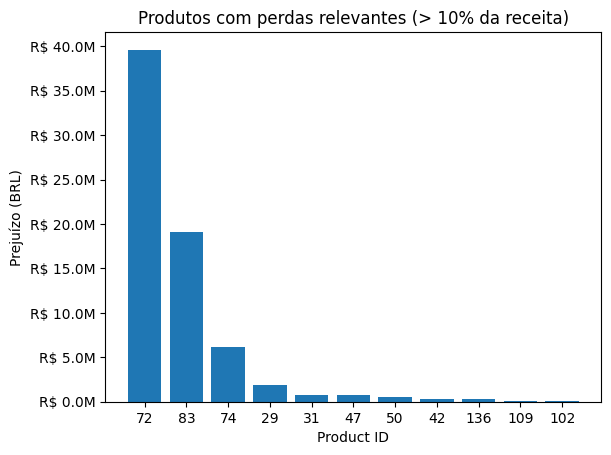

In [142]:
df_plot = (
    agg_by_product[agg_by_product['loss_pct'] > 0.1]
    .sort_values('brl_total_loss', ascending=False)
)

plt.figure()
plt.bar(df_plot['id_product'].astype(str), df_plot['brl_total_loss'])
plt.xlabel('Product ID')
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'R$ {x/1_000_000:.1f}M')
)
plt.ylabel('Prejuízo (BRL)')
plt.title('Produtos com perdas relevantes (> 10% da receita)')

plt.show()